$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ Abril de 2026   

$ \textbf{Estudo Orientado - 2026.1}$

In [1]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform, expon
import numdifftools as nd

In [2]:
rng = np.random.default_rng(seed=4)

In [3]:
# Gerar pontos de uma distribuição gama usando rng
shape = 2   # parâmetro k (forma)
scale = 1   # parâmetro θ (escala)
n_points = [500, 1_000, 5_000, 10_000, 50_000]

## Quantil fixo para o threshold
$$ 
\begin{align}
u &= \text{quantil 95\%} \\  
\frac{n_u}{n} &\approx 0.05 \\
\end{align} 
$$

In [4]:
results = []
alpha_t = 0.95

n_sim = 100
for T in tqdm(n_points):
    result = {
        'xi': [],
        'beta': []
    }
    
    for n in range(n_sim):
        # simulação dos dados gamma
        series = rng.gamma(shape=shape, scale=scale, size=T)
        
        # cálculo dos excessos e estimação do modelo por ML
        threshold = np.quantile(series, alpha_t)
        exceedances = series[series > threshold] - threshold
        xi, loc, beta = genpareto.fit(exceedances, floc=0)

        result['xi'].append(xi)
        result['beta'].append(beta)
        
    results.append({
        'size':T,
        'results': result
    })

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.72s/it]


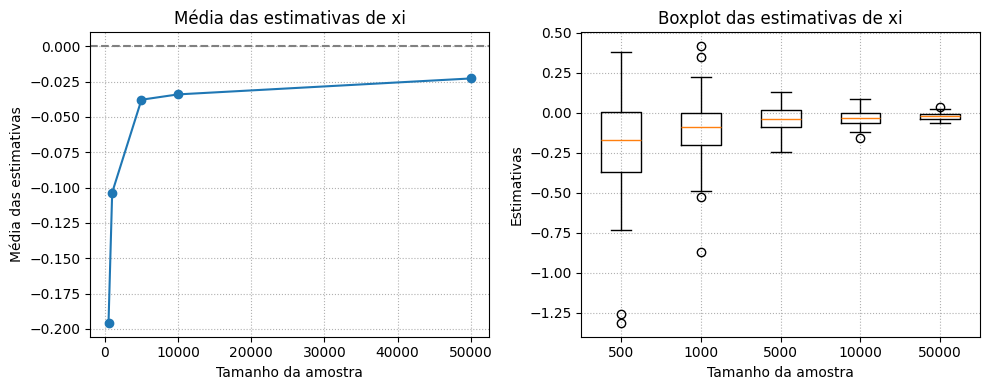

In [5]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

mean_xis = [np.mean(r['results']['xi']) for r in results]
ax[0].plot(n_points, mean_xis, marker='o')
ax[0].axhline(0, color='gray', linestyle='--')
ax[0].set_xlabel('Tamanho da amostra')
ax[0].set_ylabel('Média das estimativas')
ax[0].grid(axis='both', linestyle=':')
ax[0].set_title('Média das estimativas de xi')
        
ax[1].boxplot([r['results']['xi'] for r in results], tick_labels=[str(s) for s in n_points])
ax[1].set_xlabel('Tamanho da amostra')
ax[1].set_ylabel('Estimativas')
ax[1].grid(axis='both', linestyle=':')
ax[1].set_title('Boxplot das estimativas de xi')

fig.tight_layout()
plt.show()

## Quantil variável para o threshold
$$ 
\begin{align}
n_u &= \sqrt{n} \\
\frac{n_u}{n} &\to 0
\end{align}
$$

In [6]:
results = []

n_sim = 100
for T in tqdm(n_points):
    result = {
        'xi': [],
        'beta': []
    }
    k = int(np.sqrt(T))
    
    for n in range(n_sim):
        # simulação dos dados gamma
        series = rng.gamma(shape=shape, scale=scale, size=T)
        
        # cálculo dos excessos e estimação do modelo por ML
        threshold = np.sort(series)[-k]
        exceedances = series[series > threshold] - threshold
        xi, loc, beta = genpareto.fit(exceedances, floc=0)

        result['xi'].append(xi)
        result['beta'].append(beta)
        
    results.append({
        'size':T,
        'results': result
    })

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.50s/it]


In [7]:
[int(np.sqrt(T)) for T in n_points]

[22, 31, 70, 100, 223]

In [8]:
[100*int(np.sqrt(T))/T for T in n_points]

[4.4, 3.1, 1.4, 1.0, 0.446]

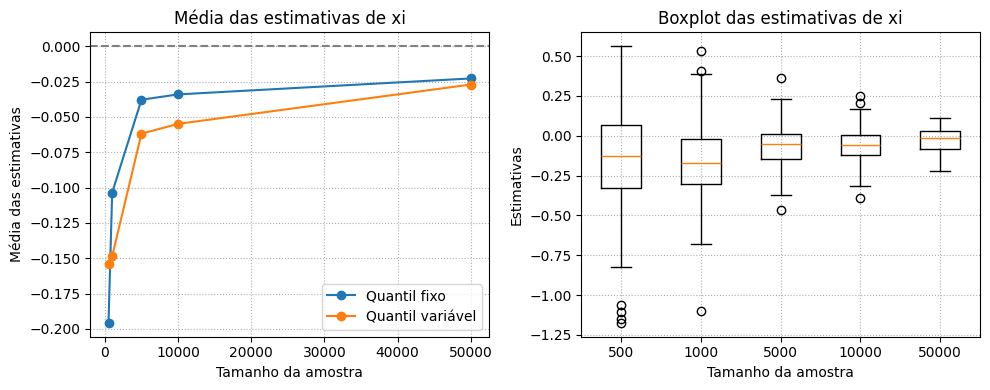

In [12]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(n_points, mean_xis, marker='o', label='Quantil fixo')
ax[0].plot(n_points, [np.mean(r['results']['xi']) for r in results], marker='o', label='Quantil variável')
ax[0].axhline(0, color='gray', linestyle='--')
ax[0].set_xlabel('Tamanho da amostra')
ax[0].set_ylabel('Média das estimativas')
ax[0].grid(axis='both', linestyle=':')
ax[0].legend()
ax[0].set_title('Média das estimativas de xi')
        
ax[1].boxplot([r['results']['xi'] for r in results], tick_labels=[str(s) for s in n_points])
ax[1].set_xlabel('Tamanho da amostra')
ax[1].set_ylabel('Estimativas')
ax[1].grid(axis='both', linestyle=':')
ax[1].set_title('Boxplot das estimativas de xi')

fig.tight_layout()
plt.show()